In [1]:
# Libraries
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray

/mnt/ssd2/animesh/VSCode/DroughtXAIPred/venv/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in '': 'india_ll_f' (default), 'india_ll_f_'. Specify layer parameter to avoid this warning.
  result = read_func(


<Axes: >

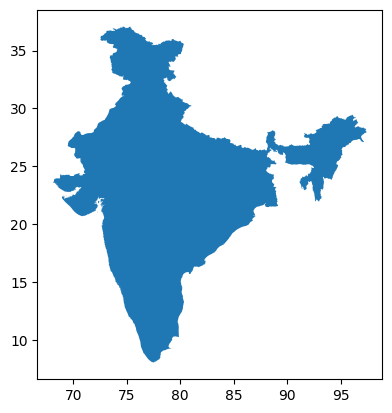

In [3]:
# Read the indian shapefile

india_shp = gpd.read_file(r"/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_shapefile/") # change the path accordingly
india_shp.plot()

In [5]:
spei = xr.open_mfdataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ERA5_monthly/SPEI/*.nc', combine='by_coords')
spei

<xarray.Dataset> Size: 163MB
Dimensions:  (time: 1022, lat: 141, lon: 141)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1940-01-01T06:00:00 ... 2025-02-01T06:...
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    SPEI1    (time, lat, lon) float64 163MB dask.array<chunksize=(1, 141, 141), meta=np.ndarray>
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [7]:
# Process SPEI data
# The dataset already has time, lat, lon dimensions
# Convert time to year-month-day string
spei_processed = spei.copy()
spei_processed['time'] = spei_processed['time'].dt.strftime('%Y-%m-%d')

spei_processed

<xarray.Dataset> Size: 163MB
Dimensions:  (time: 1022, lat: 141, lon: 141)
Coordinates:
  * time     (time) object 8kB '1940-01-01' '1940-02-01' ... '2025-02-01'
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    SPEI1    (time, lat, lon) float64 163MB dask.array<chunksize=(1, 141, 141), meta=np.ndarray>
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [8]:
t2m = xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ERA5_monthly/AuxData/data_0.nc')
t2m

<xarray.Dataset> Size: 81MB
Dimensions:     (valid_time: 1024, latitude: 141, longitude: 141)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-04-01
    expver      (valid_time) <U4 16kB ...
  * latitude    (latitude) float64 1kB 40.0 39.75 39.5 39.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 1kB 65.0 65.25 65.5 ... 99.5 99.75 100.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 81MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [9]:
# Process t2m data
t2m_processed = t2m.rename({'valid_time': 'time', 'latitude': 'lat', 'longitude': 'lon'})
t2m_processed = t2m_processed.drop_vars(['expver', 'number'], errors='ignore')

# Convert time to year-month-day string
t2m_processed['time'] = t2m_processed['time'].dt.strftime('%Y-%m-%d')

t2m_processed

<xarray.Dataset> Size: 81MB
Dimensions:  (time: 1024, lat: 141, lon: 141)
Coordinates:
  * time     (time) object 8kB '1940-01-01' '1940-02-01' ... '2025-04-01'
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    t2m      (time, lat, lon) float32 81MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [11]:
aux = xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/ERA5_monthly/AuxData/data_1.nc')
aux

<xarray.Dataset> Size: 326MB
Dimensions:     (valid_time: 1024, latitude: 141, longitude: 141)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01T06:00:00 ... 2025-...
    expver      (valid_time) <U4 16kB ...
  * latitude    (latitude) float64 1kB 40.0 39.75 39.5 39.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 1kB 65.0 65.25 65.5 ... 99.5 99.75 100.0
    number      int64 8B ...
Data variables:
    e           (valid_time, latitude, longitude) float32 81MB ...
    ro          (valid_time, latitude, longitude) float32 81MB ...
    tp          (valid_time, latitude, longitude) float32 81MB ...
    cdir        (valid_time, latitude, longitude) float32 81MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [12]:
# Process aux data
aux_processed = aux.rename({'valid_time': 'time', 'latitude': 'lat', 'longitude': 'lon'})
aux_processed = aux_processed.drop_vars(['expver', 'number'], errors='ignore')

# Convert time to year-month-day string
aux_processed['time'] = aux_processed['time'].dt.strftime('%Y-%m-%d')

aux_processed

<xarray.Dataset> Size: 326MB
Dimensions:  (time: 1024, lat: 141, lon: 141)
Coordinates:
  * time     (time) object 8kB '1940-01-01' '1940-02-01' ... '2025-04-01'
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    e        (time, lat, lon) float32 81MB ...
    ro       (time, lat, lon) float32 81MB ...
    tp       (time, lat, lon) float32 81MB ...
    cdir     (time, lat, lon) float32 81MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [13]:
# Merge all processed datasets using outer join to handle different time dimensions
merged = xr.merge([spei_processed, t2m_processed, aux_processed], join='outer')

# Filter to keep only data up to 2024-12
merged_filtered = merged.sel(time=merged['time'] <= '2024-12-01')

merged_filtered

<xarray.Dataset> Size: 568MB
Dimensions:  (time: 1020, lat: 141, lon: 141)
Coordinates:
  * time     (time) object 8kB '1940-01-01' '1940-02-01' ... '2024-12-01'
  * lat      (lat) float64 1kB 40.0 39.75 39.5 39.25 39.0 ... 5.75 5.5 5.25 5.0
  * lon      (lon) float64 1kB 65.0 65.25 65.5 65.75 ... 99.25 99.5 99.75 100.0
Data variables:
    SPEI1    (time, lat, lon) float64 162MB dask.array<chunksize=(1, 141, 141), meta=np.ndarray>
    t2m      (time, lat, lon) float32 81MB ...
    e        (time, lat, lon) float32 81MB ...
    ro       (time, lat, lon) float32 81MB ...
    tp       (time, lat, lon) float32 81MB ...
    cdir     (time, lat, lon) float32 81MB ...
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [15]:
def plot_spei(ds):
  """
  A method to plot the basic features (mean, median, standard deviation, max, min, and a raodom time)
  """
  mean = ds.SPEI1.mean(dim = 'time')
  median = ds.SPEI1.median(dim = "time")
  max = ds.SPEI1.max(dim = "time")
  min = ds.SPEI1.min(dim = "time")
  random = ds.SPEI1.isel(time = np.random.randint(0, len(ds.SPEI1.values)))
  std = ds.SPEI1.std(dim = 'time')

  fig, axs = plt.subplots(2, 3, figsize=(12, 6))
  # Plot the mean in the first subplot
  mean.plot(ax=axs[0, 0], cmap='jet')
  axs[0, 0].set_title('Mean')
  # Plot the median in the second subplot
  median.plot(ax=axs[0, 1], cmap='jet')
  axs[0, 1].set_title('Median')
  # Plot the std days in the sixth subplot
  std.plot(ax=axs[0, 2], cmap='jet')
  axs[0, 2].set_title('Std')
  # Plot the max in the third subplot
  max.plot(ax=axs[1, 0], cmap='jet')
  axs[1, 0].set_title('Max')
  # Plot the min in the fourth subplot
  min.plot(ax=axs[1, 1], cmap='jet')
  axs[1, 1].set_title('Min')
  # Plot the random days in the fifty subplot
  random.plot(ax=axs[1, 2], cmap='jet')
  axs[1, 2].set_title('Random')

  # Adjust layout
  plt.tight_layout()

  # Show the figure
  plt.show()

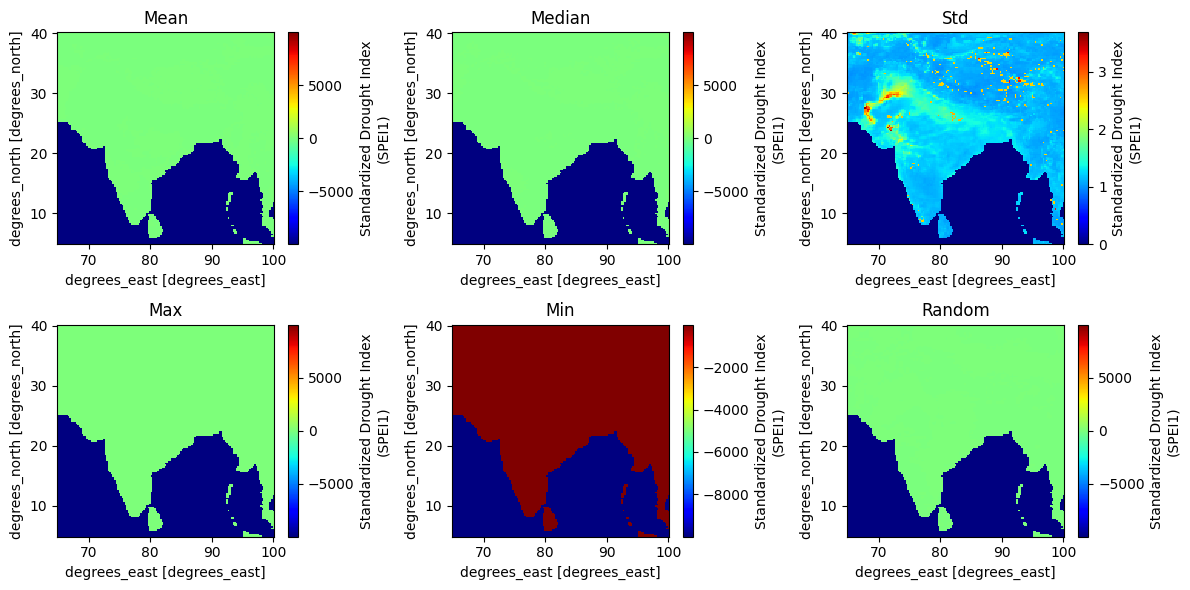

In [16]:
plot_spei(merged_filtered)

In [14]:


# Set spatial dimensions (lon=x, lat=y) for rioxarray
merged_filtered_spatial = merged_filtered.rio.set_spatial_dims(x_dim='lon', y_dim='lat')

# Write CRS and clip to shapefile
ClipData = merged_filtered_spatial.rio.write_crs(india_shp.crs).rio.clip(india_shp.geometry)

ClipData

<xarray.Dataset> Size: 388MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) object 8kB '1940-01-01' '1940-02-01' ... '2024-12-01'
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    spatial_ref  int64 8B 0
Data variables:
    SPEI1        (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
    t2m          (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    e            (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    ro           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    tp           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    cdir         (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [18]:
# Set SPEI1 values to NaN where they are above 10 or below -10
ClipData_filtered = ClipData.copy()
ClipData_filtered['SPEI1'] = ClipData_filtered['SPEI1'].where((ClipData_filtered['SPEI1'] >= -10) & (ClipData_filtered['SPEI1'] <= 10))

ClipData_filtered

<xarray.Dataset> Size: 388MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) object 8kB '1940-01-01' '1940-02-01' ... '2024-12-01'
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    spatial_ref  int64 8B 0
Data variables:
    SPEI1        (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
    t2m          (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    e            (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    ro           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    tp           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    cdir         (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

/mnt/ssd2/animesh/VSCode/DroughtXAIPred/venv/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


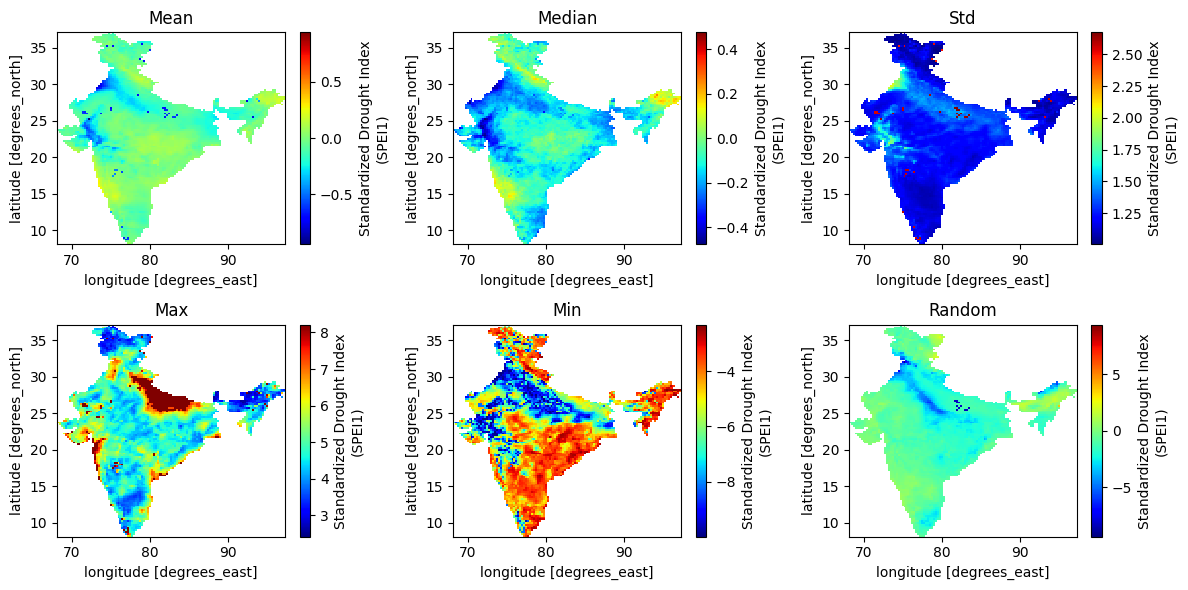

In [19]:
plot_spei(ClipData_filtered)

In [ ]:
# Classify SPEI1 values according to the classification table
def classify_spei(spei_values):
    """
    Classify SPEI values according to standard classifications:
   
    >=-0.5 : Non drought (0)
    -1.0 to -0.5: Mild drought (1)
    -1.5 to -1.0: Moderate drought (2)
    -2.0 to -1.5: Severe drought (3)
    <= -2.0: Extreme drought (4)
    """
    classified = xr.where(spei_values >= -0.5, 0, spei_values)
    # classified = xr.where((spei_values >= 1.5) & (spei_values < 2.0), 1, classified)
    # classified = xr.where((spei_values >= 1.0) & (spei_values < 1.5), 2, classified)
    # classified = xr.where((spei_values >= 0.5) & (spei_values < 1.0), 3, classified)
    # classified = xr.where((spei_values >= -0.5) & (spei_values < 0.5), 4, classified)
    classified = xr.where((spei_values >= -1.0) & (spei_values < -0.5), 1, classified)
    classified = xr.where((spei_values >= -1.5) & (spei_values < -1.0), 2, classified)
    classified = xr.where((spei_values >= -2.0) & (spei_values < -1.5), 3, classified)
    classified = xr.where(spei_values <= -2.0, 4, classified)
    return classified

# Apply classification to ClipData_filtered
ClipData_classified = ClipData_filtered.copy()
ClipData_classified['SPEI1_class'] = classify_spei(ClipData_filtered['SPEI1'])

ClipData_classified

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) object 8kB '1940-01-01' '1940-02-01' ... '2024-12-01'
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    spatial_ref  int64 8B 0
Data variables:
    SPEI1        (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
    t2m          (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    e            (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    ro           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    tp           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    cdir         (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    SPEI1_class  (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [23]:
# Convert time coordinate to datetime64[ns]
ClipData_classified['time'] = ClipData_classified['time'].astype('datetime64[ns]')
ClipData_classified

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
    spatial_ref  int64 8B 0
Data variables:
    SPEI1        (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
    t2m          (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    e            (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    ro           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    tp           (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    cdir         (time, lat, lon) float32 55MB nan nan nan nan ... nan nan nan
    SPEI1_class  (time, lat, lon) float64 111MB dask.array<chunksize=(1, 116, 117), meta=np.ndarray>
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [24]:
ClipData_classified.to_netcdf(r'Data\Ind_drought_ERA5_monthly_5class.nc')

In [27]:
data1 =  xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_drought_ERA5_monthly_5class.nc')
data1= data1.drop_vars(['spatial_ref'], errors='ignore')
data1

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
Data variables:
    SPEI1        (time, lat, lon) float64 111MB ...
    t2m          (time, lat, lon) float32 55MB ...
    e            (time, lat, lon) float32 55MB ...
    ro           (time, lat, lon) float32 55MB ...
    tp           (time, lat, lon) float32 55MB ...
    cdir         (time, lat, lon) float32 55MB ...
    SPEI1_class  (time, lat, lon) float64 111MB ...
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...

In [28]:
data1.to_netcdf(r'Data\Ind_SPEI1_ERA5_monthly_5class.nc')

In [30]:
data =  xr.open_dataset(r'/mnt/ssd2/animesh/VSCode/DroughtXAIPred/Data/Ind_SPEI1_ERA5_monthly_5class.nc')
data

<xarray.Dataset> Size: 498MB
Dimensions:      (time: 1020, lat: 116, lon: 117)
Coordinates:
  * time         (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lat          (lat) float64 928B 37.0 36.75 36.5 36.25 ... 9.0 8.75 8.5 8.25
  * lon          (lon) float64 936B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
Data variables:
    SPEI1        (time, lat, lon) float64 111MB ...
    t2m          (time, lat, lon) float32 55MB ...
    e            (time, lat, lon) float32 55MB ...
    ro           (time, lat, lon) float32 55MB ...
    tp           (time, lat, lon) float32 55MB ...
    cdir         (time, lat, lon) float32 55MB ...
    SPEI1_class  (time, lat, lon) float64 111MB ...
Attributes: (12/17)
    title:                   SPEI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 13/08/2024 12:16:55 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int
    cds_data_catalogue_url:  https://ecds.ecmwf.int/datasets/derived-drought-...